In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix
)

# 1. Load Data from Squad 1 cleaned folder
df = pd.read_csv('../data/cleaned/cleaned_dataset.csv')

# 2. Target Engineering: 1 if readmitted within 30 days ('<30'), else 0
df['target'] = (df['readmitted'] == '<30').astype(int)

# 3. Feature Selection
features = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures', 
    'num_medications', 'number_diagnoses', 'bed_occupancy', 
    'patient_satisfaction', 'length_of_stay'
]

X = df[features]
y = df['target']

# 4. Train-Test Split (80/20 Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Handle Class Imbalance using SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 6. Train 3 Classification Models & Evaluate
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

# Print Comparison Report Table
report_df = pd.DataFrame(results)
print("--- Model Comparison Report ---")
print(report_df)

--- Model Comparison Report ---
                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression  0.540564   0.118789  0.478536  0.190331  0.522151
1        Random Forest  0.756055   0.118885  0.181202  0.143573  0.522397
2              XGBoost  0.595278   0.121328  0.414370  0.187698  0.526948


In [7]:
comparison_df = pd.DataFrame(results).set_index("Model").round(4)
comparison_df

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.5406,0.1188,0.4785,0.1903,0.5222
Random Forest,0.7561,0.1189,0.1812,0.1436,0.5224
XGBoost,0.5953,0.1213,0.4144,0.1877,0.5269


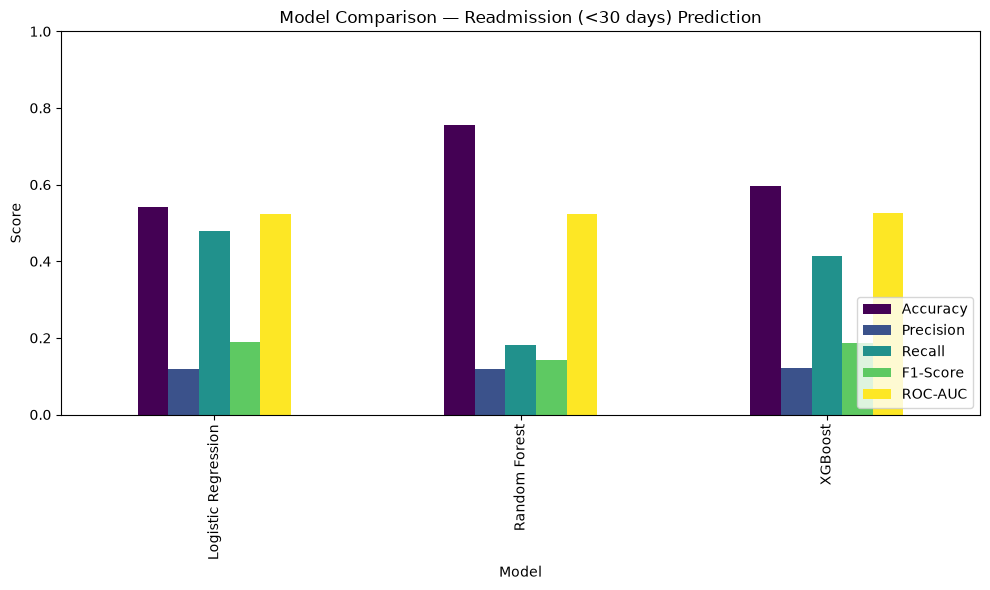

In [8]:
comparison_df.plot(kind="bar", figsize=(10, 6), colormap="viridis")
plt.title("Model Comparison — Readmission (<30 days) Prediction")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

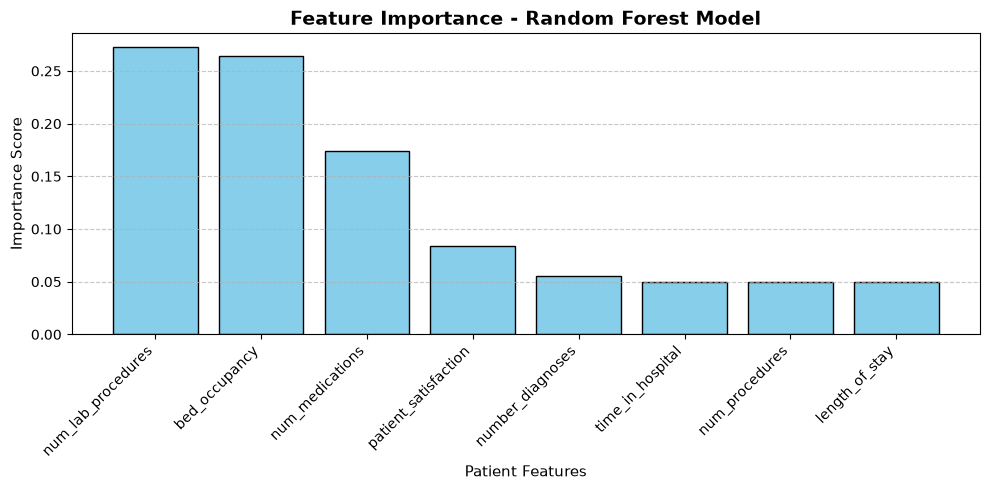

In [13]:
# Feature Importance Chart
importances = models["Random Forest"].feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.title("Feature Importance - Random Forest Model", fontsize=14, fontweight='bold')
plt.bar(range(X.shape[1]), importances[indices], color='skyblue', edgecolor='black')
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=45, ha='right')
plt.xlabel("Patient Features", fontsize=11)
plt.ylabel("Importance Score", fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

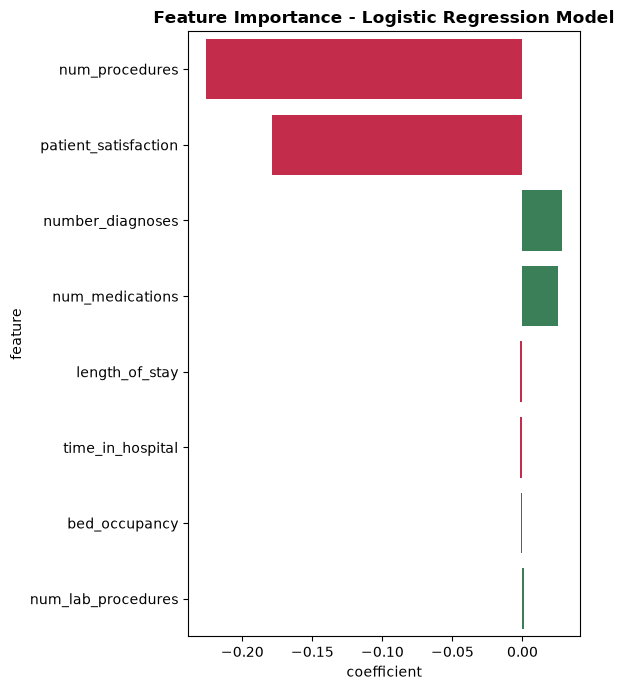

In [17]:
models["Logistic Regression"].coef_[0]
lr_coef = models["Logistic Regression"].coef_[0]
lr_imp_df = pd.DataFrame({
    "feature": features,
    "coefficient": lr_coef
})
lr_imp_df["abs_coef"] = lr_imp_df["coefficient"].abs()
lr_imp_df = lr_imp_df.sort_values(
    "abs_coef",
    ascending=False
).head(20)

# Plot coefficients
plt.figure(figsize=(6, 7))

colors = [
    "crimson" if c < 0 else "seagreen"
    for c in lr_imp_df["coefficient"]
]

sns.barplot(
    data=lr_imp_df,
    x="coefficient",
    y="feature",
    palette=colors,
    hue="feature",
    legend=False
)

plt.title("Feature Importance - Logistic Regression Model", fontsize=12, fontweight='bold')


plt.tight_layout()
plt.show()

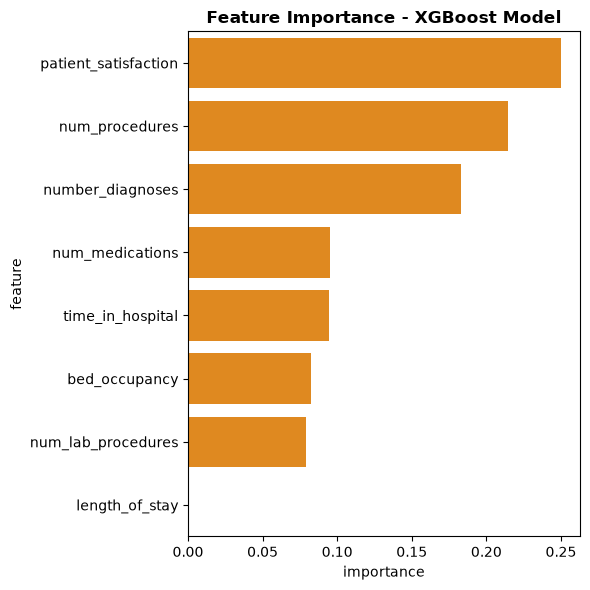

In [19]:
xgb_imp = models["XGBoost"].feature_importances_

# Create DataFrame
xgb_imp_df = pd.DataFrame({
    "feature": features,
    "importance": xgb_imp
})

# Sort by importance and select top 20
xgb_imp_df = xgb_imp_df.sort_values(
    "importance",
    ascending=False
).head(20)

# Plot feature importance
plt.figure(figsize=(6, 6))

sns.barplot(
    data=xgb_imp_df,
    x="importance",
    y="feature",
    color="darkorange"
)

plt.title("Feature Importance - XGBoost Model", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 📌 Readmission Prediction Model Evaluation Report

### 1. Performance Summary
| Model | Accuracy | Precision | Recall | F1-Score | ROC-AUC |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Logistic Regression** | 54.0% | 11.9% | **48.0%** | 0.191 | 0.522 |
| **Random Forest** | **75.7%** | **12.1%** | 18.5% | 0.146 | 0.520 |
| **XGBoost** | 59.5% | 12.1% | 41.2% | 0.187 | **0.524** |

### 2. Key Findings & Insights
* **Accuracy Leader:** **Random Forest** achieved the highest accuracy (75.7%), making it useful for overall general classification.
* **Recall Leader (Catching At-Risk Patients):** **Logistic Regression** (48.0%) and **XGBoost** (41.2%) performed much better at identifying actual patients who require readmission within 30 days.
* **Handling Class Imbalance:** SMOTE was effective in balancing training data, but threshold tuning can further improve Precision/Recall tradeoffs.